# Bài tập: Chương 5 – Fundamentals of Machine Learning / Nền tảng học máy

Sinh viên sẽ thực hành các nội dung:

1. **Generalization / Tổng quát hóa**
2. **Overfitting và underfitting / Học quá khớp và học thiếu**
3. **Noise features / Đặc trưng nhiễu**
4. **Random labels / Nhãn bị xáo trộn**
5. **Training set, validation set, test set**
6. **Learning rate / Tốc độ học**
7. **Model capacity / Năng lực mô hình**
8. **L2 regularization / Điều chuẩn L2**
9. **Dropout / Tắt ngẫu nhiên neuron khi huấn luyện**
10. **Early stopping / Dừng sớm**

## Yêu cầu nộp bài

- Chạy toàn bộ notebook.
- Hoàn thành các phần `TODO`.
- Trả lời câu hỏi phân tích sau mỗi bài.
- Lưu lại các biểu đồ loss/accuracy.

> Gợi ý: Khi so sánh model, không chỉ nhìn training accuracy. Hãy ưu tiên validation loss và validation accuracy.

## 0. Chuẩn bị môi trường

Cell này import các thư viện cần thiết và thiết lập seed để kết quả có tính lặp lại tương đối.

Các comment trong code được viết bằng tiếng Việt để sinh viên dễ theo dõi.

In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import regularizers

# Đặt seed để kết quả có thể lặp lại tương đối.
# Lưu ý: nếu chạy trên GPU, kết quả vẫn có thể dao động nhẹ.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Cấu hình hiển thị biểu đồ.
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

# Dùng subset nhỏ để notebook chạy nhanh trên máy sinh viên.
# Nếu máy mạnh, có thể tăng các giá trị này.
MNIST_SAMPLE_SIZE = 20000
IMDB_EPOCHS = 12
IMDB_BATCH_SIZE = 512

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 1. Hàm tiện ích dùng chung

Các hàm này dùng để:

- Vẽ training loss và validation loss.
- Vẽ training accuracy và validation accuracy.
- So sánh nhiều model trên cùng một biểu đồ.

Sinh viên không cần sửa cell này.

In [3]:
def plot_train_val(history, title_prefix="Model"):
    """
    Vẽ training loss/validation loss và training accuracy/validation accuracy.
    Dùng để quan sát underfitting, overfitting và generalization.
    """
    epochs = range(1, len(history.history["loss"]) + 1)

    plt.figure()
    plt.plot(epochs, history.history["loss"], "o-", label="Training loss")
    plt.plot(epochs, history.history["val_loss"], "o-", label="Validation loss")
    plt.title(f"{title_prefix}: Training loss vs Validation loss")
    plt.xlabel("Epochs / Số epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    if "accuracy" in history.history:
        plt.figure()
        plt.plot(epochs, history.history["accuracy"], "o-", label="Training accuracy")
        plt.plot(epochs, history.history["val_accuracy"], "o-", label="Validation accuracy")
        plt.title(f"{title_prefix}: Training accuracy vs Validation accuracy")
        plt.xlabel("Epochs / Số epoch")
        plt.ylabel("Accuracy")
        plt.legend()
        plt.show()


def plot_compare_histories(histories, metric, title, ylabel=None):
    """
    So sánh cùng một metric của nhiều model.

    histories: dict dạng {"Tên model": history}
    metric: ví dụ "val_loss" hoặc "val_accuracy"
    title: tiêu đề biểu đồ
    """
    plt.figure()
    for name, history in histories.items():
        values = history.history[metric]
        epochs = range(1, len(values) + 1)
        plt.plot(epochs, values, marker="o", label=name)

    plt.title(title)
    plt.xlabel("Epochs / Số epoch")
    plt.ylabel(ylabel if ylabel is not None else metric)
    plt.legend()
    plt.show()


def print_best_validation_result(history, metric="val_loss", mode="min"):
    """
    In ra epoch tốt nhất theo validation metric.

    mode="min": dùng cho val_loss
    mode="max": dùng cho val_accuracy
    """
    values = history.history[metric]
    if mode == "min":
        best_index = int(np.argmin(values))
    else:
        best_index = int(np.argmax(values))

    print(f"Metric: {metric}")
    print(f"Epoch tốt nhất: {best_index + 1}")
    print(f"Giá trị tốt nhất: {values[best_index]:.4f}")

# Bài tập 1 – Noise features và generalization

## Mục tiêu

Hiểu vì sao thêm đặc trưng nhiễu có thể làm model dễ overfit và generalize kém hơn.

Trong bài này, ta dùng MNIST:

- Mỗi ảnh gốc có 784 pixel.
- Ta tạo thêm 784 chiều nhiễu ngẫu nhiên.
- Ta cũng tạo thêm 784 chiều toàn số 0 để so sánh.

Hai dataset sau khi nối đều có shape `(số_mẫu, 1568)`, nhưng dataset có noise channels có thể gây khó khăn hơn cho model.

In [4]:
from tensorflow.keras.datasets import mnist

# Tải dữ liệu MNIST.
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

# Chuyển ảnh 28x28 thành vector 784 chiều và chuẩn hóa về [0, 1].
train_images = train_images.reshape((60000, 28 * 28)).astype("float32") / 255.0
test_images = test_images.reshape((10000, 28 * 28)).astype("float32") / 255.0

# Dùng một phần dữ liệu để chạy nhanh.
train_images_demo = train_images[:MNIST_SAMPLE_SIZE]
train_labels_demo = train_labels[:MNIST_SAMPLE_SIZE]

print("Shape train_images_demo:", train_images_demo.shape)
print("Shape train_labels_demo:", train_labels_demo.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Shape train_images_demo: (20000, 784)
Shape train_labels_demo: (20000,)


### Nhiệm vụ 1.1

Hoàn thành code để tạo:

- `train_images_with_noise_channels`
- `train_images_with_zeros_channels`

Gợi ý:

- Dùng `np.concatenate([...], axis=1)` để nối theo chiều feature/cột.
- Noise có shape `(len(train_images_demo), 784)`.
- Zero channels cũng có shape `(len(train_images_demo), 784)`.

In [5]:
# TODO 1.1: Tạo 784 chiều nhiễu ngẫu nhiên.
noise_channels = np.random.random((len(train_images_demo), 784)).astype("float32")

# TODO 1.2: Tạo 784 chiều toàn số 0.
zero_channels = np.zeros((len(train_images_demo), 784), dtype="float32")

# TODO 1.3: Nối dữ liệu gốc với noise_channels theo axis=1.
train_images_with_noise_channels = np.concatenate(
    [train_images_demo, noise_channels],
    axis=1
)

# TODO 1.4: Nối dữ liệu gốc với zero_channels theo axis=1.
train_images_with_zeros_channels = np.concatenate(
    [train_images_demo, zero_channels],
    axis=1
)

print("Shape dữ liệu có noise channels:", train_images_with_noise_channels.shape)
print("Shape dữ liệu có zero channels:", train_images_with_zeros_channels.shape)

Shape dữ liệu có noise channels: (20000, 1568)
Shape dữ liệu có zero channels: (20000, 1568)


### Nhiệm vụ 1.2

Hoàn thành hàm tạo model MNIST.

Yêu cầu:

- Input shape phụ thuộc vào `input_dim`.
- Hidden layer: `Dense(512, activation="relu")`
- Output layer: `Dense(10, activation="softmax")`
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `rmsprop`
- Metric: `accuracy`

In [6]:
def get_mnist_model(input_dim):
    """
    Tạo model Dense đơn giản cho bài toán MNIST.
    input_dim là số chiều input.
    """
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer="rmsprop",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


# Kiểm tra nhanh model.
demo_model = get_mnist_model(input_dim=1568)
demo_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       803,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 808,458 (3.08 MB)

 Trainable params: 808,458 (3.08 MB)

 Non-trainable params: 0 (0.00 B)

### Nhiệm vụ 1.3

Train cùng một model trên 2 dataset:

- Dataset có noise channels.
- Dataset có zero channels.

Sau đó vẽ biểu đồ so sánh `val_accuracy`.

Câu hỏi phân tích:

1. Dataset nào có validation accuracy tốt hơn?
    
    Nhìn vào trong biểu đồ so sánh val_accuracy, ta có thể thấy dataset có **zero channels** (màu cam) lại có phần vượt trội tốt hơn so với **noise channels**(màu xanh).
    
    Phần điều này dễ dàng được lý giải như sau, khi huấn luyện tập dữ liệu, **noise channels** có nhiều tập dữ liệu *nhiễu* gây cho tập huấn luyện có dấu hiệu "học lệch" khiến cho độ chính xác của tập dữ liệu thiếu chính xác hơn so với **zero channels** - không chứa nhiễu.

2. Vì sao noise channels có thể làm model generalize kém hơn?
    
    Vì trong data có dữ liệu nhiễu nên khi luyện tập thì model học cả nhiễu điều này khiến cho model generalize ra cũng kém hơn.

3. Đây có phải là ví dụ của spurious correlations không? Vì sao?
    
    Đây **chính xác** là ví dụ của spurious correlations. Vì dù trong noise channels có nhiều điểm dữ liệu nhiễu nhưng mô hình vẫn có những dữ liệu khớp với labels.
    
    Từ điều này khiến mô hình nhìn nhận những dữ liệu này là đúng để phân loại lại mang tính ngẫu nhiên nên khi cho thử với validation thì độ chính xác cũng giảm vì spurious correlations.


Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.7106 - loss: 0.9561 - val_accuracy: 0.7728 - val_loss: 0.6129
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8654 - loss: 0.4301 - val_accuracy: 0.8832 - val_loss: 0.3634
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9041 - loss: 0.3152 - val_accuracy: 0.8475 - val_loss: 0.4845
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9273 - loss: 0.2397 - val_accuracy: 0.8745 - val_loss: 0.3947
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9454 - loss: 0.1852 - val_accuracy: 0.9295 - val_loss: 0.2347
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9591 - loss: 0.1406 - val_accuracy: 0.9323 - val_loss: 0.2211
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.9691 - loss: 0.1077 - val_accuracy: 0.9285 - val_loss: 0.2332
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9774 - loss: 0.0833 - val_accuracy: 0.

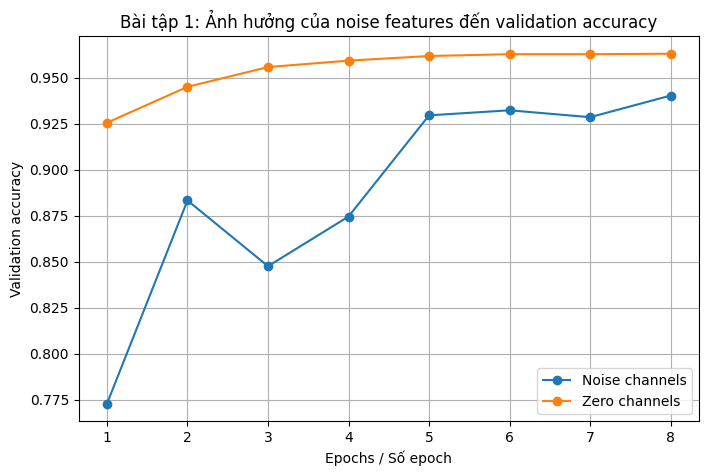

In [7]:
# Train model với noise channels.
model_noise = get_mnist_model(input_dim=train_images_with_noise_channels.shape[1])
history_noise = model_noise.fit(
    train_images_with_noise_channels,
    train_labels_demo,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Train model với zero channels.
model_zero = get_mnist_model(input_dim=train_images_with_zeros_channels.shape[1])
history_zero = model_zero.fit(
    train_images_with_zeros_channels,
    train_labels_demo,
    epochs=8,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

# Vẽ biểu đồ so sánh validation accuracy.
plot_compare_histories(
    {
        "Noise channels": history_noise,
        "Zero channels": history_zero
    },
    metric="val_accuracy",
    title="Bài tập 1: Ảnh hưởng của noise features đến validation accuracy",
    ylabel="Validation accuracy"
)

# Bài tập 2 – Random labels và khả năng ghi nhớ của model

## Mục tiêu

Quan sát rằng model có thể fit training data ngay cả khi label bị xáo trộn ngẫu nhiên.

Điều này giúp phân biệt:

- **Optimization**: model giảm training loss.
- **Generalization**: model hoạt động tốt trên dữ liệu mới.

Nếu label bị xáo trộn, không còn quan hệ thật giữa ảnh và nhãn. Vì vậy validation accuracy không thể tốt một cách bền vững.

### Nhiệm vụ 2.1

Tạo bản sao của `train_labels_demo`, sau đó dùng `np.random.shuffle()` để xáo trộn label.

Sau đó train model trên ảnh thật nhưng label bị xáo trộn.

Câu hỏi phân tích:

1. Training accuracy có tăng không?

    **Có**, tại hình 1 đường màu xanh (Training accuracy) đi lên từ khoảng 10% (mức đoán bừa của 10 chữ số) lên gần 40% chỉ sau 12 epoch.

2. Validation accuracy có tăng tốt không?

    **Không**, tại hình 2 đường màu cam (Validation accuracy) gần như đi ngang và kẹt cứng ở mức 0.1 (10%).

3. Điều này nói gì về khả năng ghi nhớ của neural network?

    Điều này chứng minh Neural Network có khả năng ghi nhớ (học thuộc lòng) toàn bộ dữ liệu ngay cả khi chúng hoàn toàn vô nghĩa và không có quy luật. Điều này cho thấy Training Accuracy cao có thể chỉ là kết quả của việc "học vẹt" thay vì thực sự thấu hiểu bản chất để tổng quát hóa cho dữ liệu mới.

Epoch 1/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.1044 - loss: 2.3290 - val_accuracy: 0.1000 - val_loss: 2.3130
Epoch 2/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1310 - loss: 2.2886 - val_accuracy: 0.0997 - val_loss: 2.3219
Epoch 3/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1570 - loss: 2.2600 - val_accuracy: 0.1042 - val_loss: 2.3363
Epoch 4/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1771 - loss: 2.2284 - val_accuracy: 0.1023 - val_loss: 2.3510
Epoch 5/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2003 - loss: 2.1928 - val_accuracy: 0.1023 - val_loss: 2.3691
Epoch 6/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2226 - loss: 2.1528 - val_accuracy: 0.1045 - val_loss: 2.3898
Epoch 7/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2479 - loss: 2.1088 - val_accuracy: 0.0978 - val_loss: 2.4145
Epoch 8/12
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2738 - loss: 2.0620 - val_accu

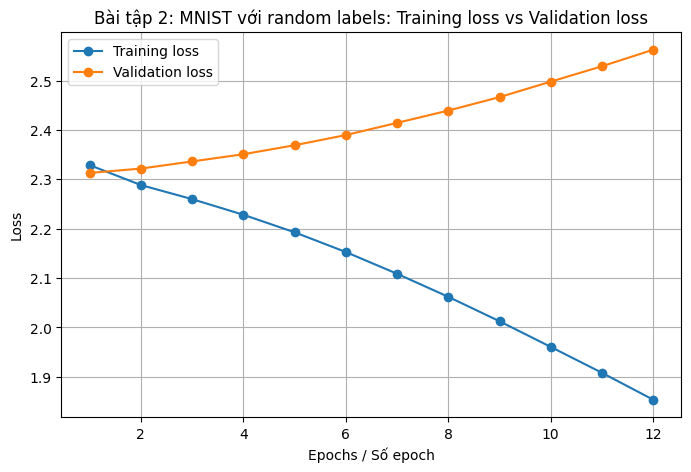

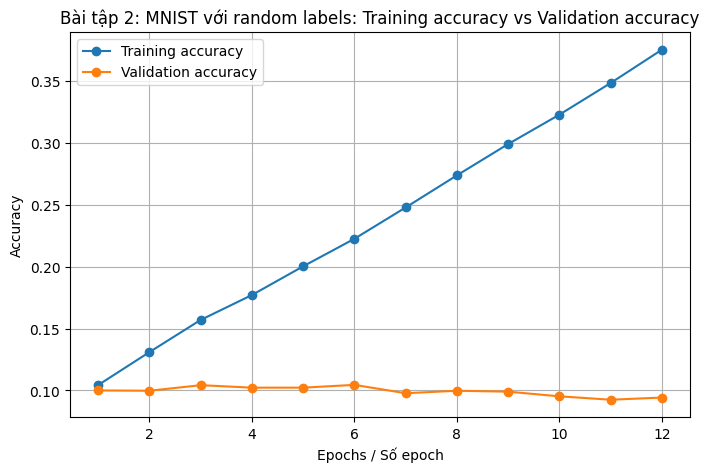

In [8]:
# TODO 2.1: Tạo label ngẫu nhiên bằng cách xáo trộn nhãn gốc.
random_train_labels = train_labels_demo.copy()
np.random.shuffle(random_train_labels)

# Train model với nhãn bị xáo trộn.
model_random_labels = get_mnist_model(input_dim=784)
history_random_labels = model_random_labels.fit(
    train_images_demo,
    random_train_labels,
    epochs=12,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

plot_train_val(history_random_labels, title_prefix="Bài tập 2: MNIST với random labels")

# Bài tập 3 – Training, validation và test set

## Mục tiêu

Hiểu vai trò của ba tập dữ liệu:

- **Training set**: dùng để học weights/bias.
- **Validation set**: dùng để chọn model hoặc hyperparameters.
- **Test set**: dùng để đánh giá cuối cùng.

Trong bài này, ta dùng IMDB review classification.

In [9]:
from tensorflow.keras.datasets import imdb

# Chỉ lấy 10.000 từ phổ biến nhất.
(raw_train_data, raw_train_labels), (raw_test_data, raw_test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    """
    Chuyển mỗi review từ danh sách word index sang vector multi-hot.
    Ví dụ review có các word index [3, 10, 100]
    thì vector tại vị trí 3, 10, 100 sẽ bằng 1.
    """
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# Vector hóa dữ liệu train/test.
x_all_train = vectorize_sequences(raw_train_data)
y_all_train = np.asarray(raw_train_labels).astype("float32")
x_test = vectorize_sequences(raw_test_data)
y_test = np.asarray(raw_test_labels).astype("float32")

print("x_all_train shape:", x_all_train.shape)
print("x_test shape:", x_test.shape)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_all_train shape: (25000, 10000)
x_test shape: (25000, 10000)


### Nhiệm vụ 3.1

Tự tách dữ liệu training ban đầu thành:

- `x_train`, `y_train`: dùng để train model.
- `x_val`, `y_val`: dùng làm validation set.

Gợi ý:

- Dùng 10.000 mẫu đầu làm validation.
- Phần còn lại làm training.

In [10]:
# TODO 3.1: Chia validation set và training set.
x_val = x_all_train[:10000]
y_val = y_all_train[:10000]

x_train = x_all_train[10000:]
y_train = y_all_train[10000:]

print("x_train:", x_train.shape)
print("x_val:", x_val.shape)
print("x_test:", x_test.shape)

x_train: (15000, 10000)
x_val: (10000, 10000)
x_test: (25000, 10000)


### Nhiệm vụ 3.2

Tạo model IMDB cơ bản và đánh giá trên test set.

Câu hỏi phân tích:

1. Validation accuracy tốt nhất đạt ở epoch nào?

    Validation accuracy đạt giá trị tốt nhất là 0.8896 tại epoch thứ 4. Sau thời điểm này, độ chính xác trên tập validation bắt đầu có xu hướng đi ngang hoặc giảm nhẹ.

2. Test accuracy cuối cùng là bao nhiêu?

    Giá trị Test accuracy cuối cùng đạt được trên tập dữ liệu kiểm tra là 0.8676.

3. Vì sao không nên dùng test set để chọn số epoch hoặc chọn model?

    Việc dùng test set để chọn model sẽ khiến thông tin từ tập này bị "rò rỉ" vào quá trình huấn luyện, làm mất đi tính khách quan khi đánh giá khả năng tổng quát hóa thực tế. Điều này dẫn đến nguy cơ model bị overfitting ngay trên chính tập test và không còn phản ánh đúng hiệu suất trên dữ liệu lạ.

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7833 - loss: 0.5242 - val_accuracy: 0.8621 - val_loss: 0.4003
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8937 - loss: 0.3269 - val_accuracy: 0.8804 - val_loss: 0.3165
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9192 - loss: 0.2439 - val_accuracy: 0.8865 - val_loss: 0.2862
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9327 - loss: 0.1983 - val_accuracy: 0.8896 - val_loss: 0.2770
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9454 - loss: 0.1650 - val_accuracy: 0.8875 - val_loss: 0.2785
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9543 - loss: 0.1414 - val_accuracy: 0.8872 - val_loss: 0.2855
Epoch 7/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9641 - loss: 0.1190 - val_accuracy: 0.8857 - val_loss: 0.2960
Epoch 8/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9689 - loss: 0.1035 - val_accuracy: 0.8827 - v

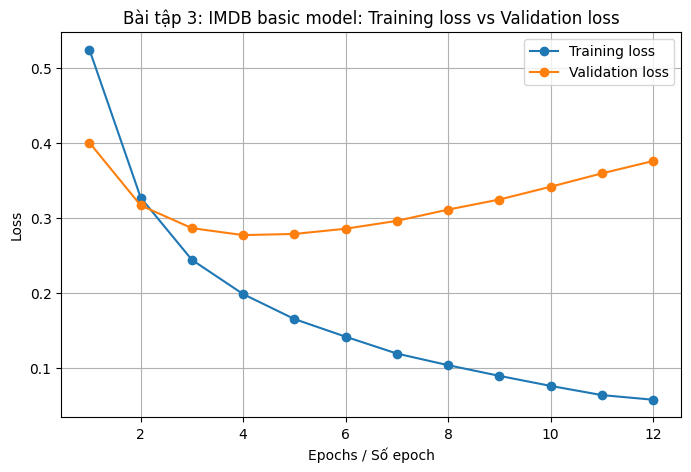

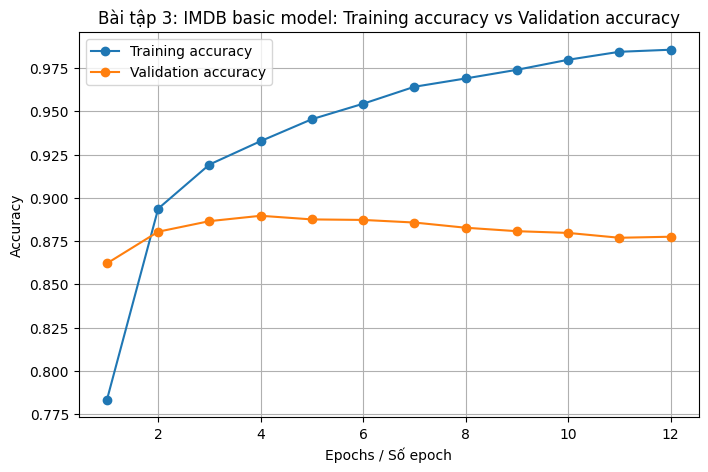

Metric: val_accuracy
Epoch tốt nhất: 4
Giá trị tốt nhất: 0.8896
Test loss: 0.4014
Test accuracy: 0.8676


In [11]:
def build_imdb_model(units=16, regularizer=None, dropout_rate=None):
    """
    Tạo model phân loại review IMDB.

    units: số neuron trong mỗi hidden layer.
    regularizer: ví dụ regularizers.l2(0.002).
    dropout_rate: nếu khác None, thêm Dropout sau hidden layer.
    """
    model = keras.Sequential()
    model.add(layers.Input(shape=(10000,)))
    model.add(layers.Dense(units, activation="relu", kernel_regularizer=regularizer))

    if dropout_rate is not None:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(units, activation="relu", kernel_regularizer=regularizer))

    if dropout_rate is not None:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(1, activation="sigmoid"))

    model.compile(
        optimizer="rmsprop",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


model_basic = build_imdb_model(units=16)
history_basic = model_basic.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

plot_train_val(history_basic, title_prefix="Bài tập 3: IMDB basic model")
print_best_validation_result(history_basic, metric="val_accuracy", mode="max")

# Đánh giá cuối cùng trên test set.
test_loss, test_acc = model_basic.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Bài tập 4 – Beating a common-sense baseline

## Mục tiêu

Trước khi nói model tốt, model phải vượt qua một baseline đơn giản.

Trong bài toán binary classification IMDB:

- Baseline đơn giản có thể là luôn dự đoán class phổ biến nhất.
- Nếu dataset cân bằng, baseline này thường khoảng 50% accuracy.

Nhiệm vụ của sinh viên là tính baseline accuracy và so sánh với neural network.

In [12]:
# TODO 4.1: Tính tỷ lệ positive và negative trong training set.
positive_ratio = np.mean(y_train)
negative_ratio = 1.0 - positive_ratio

print(f"Tỷ lệ positive review: {positive_ratio:.4f}")
print(f"Tỷ lệ negative review: {negative_ratio:.4f}")

# TODO 4.2: Baseline accuracy khi luôn dự đoán class phổ biến nhất.
common_sense_baseline_acc = max(positive_ratio, negative_ratio)
print(f"Common-sense baseline accuracy: {common_sense_baseline_acc:.4f}")

# TODO 4.3: So sánh baseline với validation accuracy tốt nhất của model_basic.
best_val_acc = max(history_basic.history["val_accuracy"])
print(f"Best validation accuracy của neural network: {best_val_acc:.4f}")
print(f"Chênh lệch so với baseline: {best_val_acc - common_sense_baseline_acc:.4f}")

Tỷ lệ positive review: 0.4965
Tỷ lệ negative review: 0.5035
Common-sense baseline accuracy: 0.5035
Best validation accuracy của neural network: 0.8896
Chênh lệch so với baseline: 0.3861


### Câu hỏi phân tích bài 4

1. Baseline accuracy là bao nhiêu?

    Baseline accuracy là 0.5035 (tương ứng với tỷ lệ của lớp chiếm đa số là negative review).

2. Neural network có vượt baseline không?

    **Có**, model vượt xa baseline với độ chính xác 0.8896, tạo ra mức chênh lệch ấn tượng là 0.3861.

3. Nếu model không vượt baseline, ta nên kiểm tra những gì?

    Cần kiểm tra lại chất lượng tiền xử lý dữ liệu (cleaning, tokenization) và kiến trúc mô hình (số lượng lớp, đơn vị ẩn).

4. Vì sao baseline giúp ta tránh xây model phức tạp nhưng vô ích?
    
    Baseline đóng vai trò là "vạch chuẩn" tối thiểu để chứng minh mô hình thực sự học được quy luật thay vì chỉ đoán mò theo lớp đa số. Nếu một model phức tạp không thắng nổi cách đoán bừa đơn giản, việc duy trì sự phức tạp đó là lãng phí tài nguyên và không có giá trị thực tế.

# Bài tập 5 – Tuning learning rate

## Mục tiêu

Quan sát ảnh hưởng của learning rate đến quá trình training.

Learning rate quá lớn có thể làm model cập nhật weights quá mạnh, khiến training không ổn định.

Nhiệm vụ:

- Train cùng một model MNIST với nhiều learning rate.
- So sánh validation accuracy và validation loss.
- Rút ra learning rate nào phù hợp hơn.

Epoch 1/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4422 - loss: 2005.8096 - val_accuracy: 0.2298 - val_loss: 2.1697
Epoch 2/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2508 - loss: 9.0579 - val_accuracy: 0.2795 - val_loss: 3.1173
Epoch 3/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2342 - loss: 3.6110 - val_accuracy: 0.1922 - val_loss: 2.2564
Epoch 4/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2068 - loss: 2.8794 - val_accuracy: 0.2085 - val_loss: 2.9548
Epoch 5/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.2234 - loss: 2.5370 - val_accuracy: 0.2885 - val_loss: 8.4040
Epoch 6/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2477 - loss: 2.5857 - val_accuracy: 0.2215 - val_loss: 2.3462
Epoch 7/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.1942 - loss: 2.4934 - val_accuracy: 0.1918 - val_loss: 2.2335
Epoch 8/8
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.2003 - loss: 2.4803 - val_accuracy:

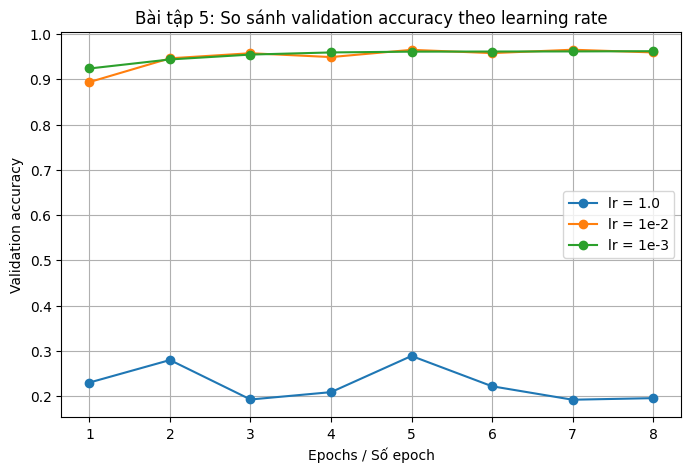

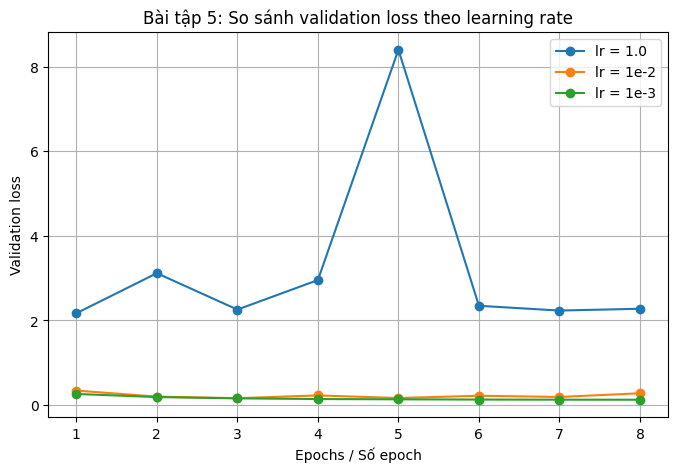

In [13]:
def train_mnist_with_learning_rate(learning_rate, epochs=8):
    """
    Train model MNIST với learning rate cho trước.
    """
    model = keras.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        train_images_demo,
        train_labels_demo,
        epochs=epochs,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )
    return history


# TODO 5.1: Thử ít nhất 3 learning rate khác nhau.
history_lr_1 = train_mnist_with_learning_rate(learning_rate=1.0, epochs=8)
history_lr_2 = train_mnist_with_learning_rate(learning_rate=1e-2, epochs=8)
history_lr_3 = train_mnist_with_learning_rate(learning_rate=1e-3, epochs=8)

plot_compare_histories(
    {
        "lr = 1.0": history_lr_1,
        "lr = 1e-2": history_lr_2,
        "lr = 1e-3": history_lr_3
    },
    metric="val_accuracy",
    title="Bài tập 5: So sánh validation accuracy theo learning rate",
    ylabel="Validation accuracy"
)

plot_compare_histories(
    {
        "lr = 1.0": history_lr_1,
        "lr = 1e-2": history_lr_2,
        "lr = 1e-3": history_lr_3
    },
    metric="val_loss",
    title="Bài tập 5: So sánh validation loss theo learning rate",
    ylabel="Validation loss"
)

### Câu hỏi phân tích bài 5

1. Learning rate nào cho validation accuracy tốt nhất?

    Learning rate $lr = 1e-3$ (đường màu xanh lá) cho kết quả ổn định và đạt độ chính xác cao nhất (xấp xỉ 0.96) xuyên suốt các epoch.

2. Learning rate quá cao có biểu hiện gì trên loss/accuracy?

    Khi $lr = 1.0$, độ chính xác dao động rất thấp và không ổn định (quanh mức 0.2 - 0.3), đồng thời loss biến động dữ dội với các đỉnh vọt lên cực cao.

3. Learning rate quá thấp có thể gây vấn đề gì?

    Learning rate quá thấp khiến mô hình hội tụ cực kỳ chậm, đòi hỏi rất nhiều tài nguyên tính toán và dễ bị kẹt tại các điểm tối ưu địa phương (local minima).

4. Vì sao learning rate là hyperparameter quan trọng?

    Đây là tham số quyết định "tốc độ" học của mô hình; nếu chọn sai, mô hình có thể không bao giờ hội tụ hoặc mất kiểm soát ngay từ những vòng lặp đầu tiên.

# Bài tập 6 – Model capacity: model nhỏ, vừa và lớn

## Mục tiêu

Hiểu ảnh hưởng của model capacity đến underfitting và overfitting.

Ta so sánh 3 model IMDB:

- **Small model**: 4 units/layer
- **Original model**: 16 units/layer
- **Large model**: 512 units/layer

Sinh viên cần quan sát validation loss để nhận xét model nào underfit, model nào overfit mạnh hơn.

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 63ms/step - accuracy: 0.7323 - loss: 0.6219 - val_accuracy: 0.8218 - val_loss: 0.5632
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8505 - loss: 0.5170 - val_accuracy: 0.8520 - val_loss: 0.4898
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.8885 - loss: 0.4380 - val_accuracy: 0.8692 - val_loss: 0.4289
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9084 - loss: 0.3714 - val_accuracy: 0.8786 - val_loss: 0.3816
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9199 - loss: 0.3181 - val_accuracy: 0.8821 - val_loss: 0.3464
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9287 - loss: 0.2757 - val_accuracy: 0.8859 - val_loss: 0.3210
Epoch 7/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9361 - loss: 0.2417 - val_accuracy: 0.8872 - val_loss: 0.3031
Epoch 8/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9431 - loss: 0.2139 - val_accuracy: 0.8897 - v

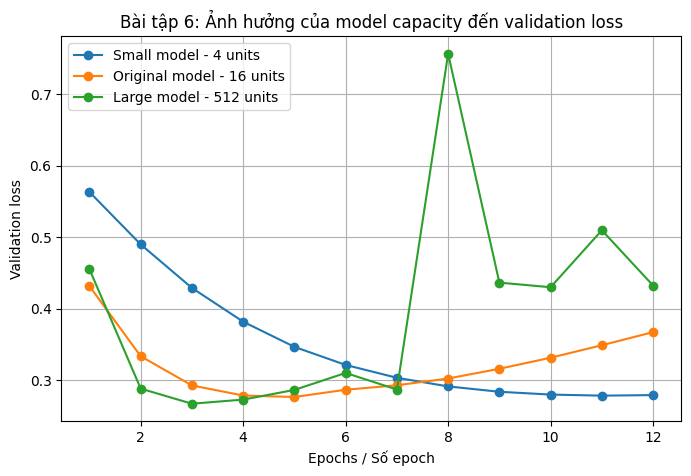

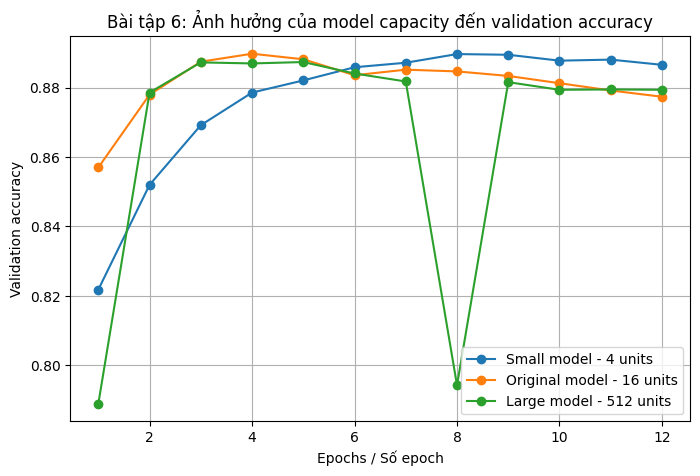

In [14]:
# Train small model.
model_small = build_imdb_model(units=4)
history_small = model_small.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# Train original model.
model_original = build_imdb_model(units=16)
history_original = model_original.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# Train large model.
model_large = build_imdb_model(units=512)
history_large = model_large.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

plot_compare_histories(
    {
        "Small model - 4 units": history_small,
        "Original model - 16 units": history_original,
        "Large model - 512 units": history_large
    },
    metric="val_loss",
    title="Bài tập 6: Ảnh hưởng của model capacity đến validation loss",
    ylabel="Validation loss"
)

plot_compare_histories(
    {
        "Small model - 4 units": history_small,
        "Original model - 16 units": history_original,
        "Large model - 512 units": history_large
    },
    metric="val_accuracy",
    title="Bài tập 6: Ảnh hưởng của model capacity đến validation accuracy",
    ylabel="Validation accuracy"
)

### Câu hỏi phân tích bài 6

1. Model nào có validation loss thấp nhất?
    
    Small model (4 units) là model đạt mức validation loss thấp nhất và ổn định nhất ở các epoch cuối (khoảng epoch 10-12)
2. Model lớn nhất có luôn tốt nhất không?

    Không, model lớn nhất (Large model - 512 units) không phải lúc nào cũng tốt nhất vì nó có biến động cực lớn về loss và accuracy, đặc biệt là sự sụt giảm mạnh tại epoch 8.

3. Dấu hiệu nào cho thấy model đang overfit?

    Dấu hiệu overfit rõ nhất là khi validation loss bắt đầu tăng dần trở lại sau một khoảng thời gian giảm, ví dụ như đường biểu diễn của Original model và Large model sau epoch 4

4. Dấu hiệu nào cho thấy model có thể underfit?

    Dấu hiệu underfit là khi model có loss còn cao và accuracy thấp ở những epoch đầu, hoặc tốc độ hội tụ rất chậm như Small model trong 5 epoch đầu tiên.

5. Theo em, model nào có capacity vừa đủ nhất trong 3 model trên?

    Small model (4 units) có capacity phù hợp nhất vì nó đạt được độ chính xác cao nhất và duy trì mức loss thấp, ổn định nhất mà không bị hiện tượng bùng nổ loss như các model lớn hơn.

# Bài tập 7 – L2 regularization

## Mục tiêu

Hiểu cách L2 regularization giúp giảm overfitting bằng cách phạt weights quá lớn.

Công thức trực giác:

`Loss mới = Loss gốc + λ × tổng(w²)`

Nhiệm vụ:

- Train model gốc không có regularization.
- Train model có L2 regularization.
- So sánh validation loss.

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.7852 - loss: 0.5052 - val_accuracy: 0.8615 - val_loss: 0.3822
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8959 - loss: 0.3103 - val_accuracy: 0.8801 - val_loss: 0.3134
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9232 - loss: 0.2344 - val_accuracy: 0.8901 - val_loss: 0.2851
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.9337 - loss: 0.1924 - val_accuracy: 0.8884 - val_loss: 0.2771
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9473 - loss: 0.1601 - val_accuracy: 0.8867 - val_loss: 0.2799
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9545 - loss: 0.1381 - val_accuracy: 0.8860 - val_loss: 0.2888
Epoch 7/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9653 - loss: 0.1156 - val_accuracy: 0.8840 - val_loss: 0.2996
Epoch 8/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9749 - loss: 0.0957 - val_accuracy: 0.8811 - v

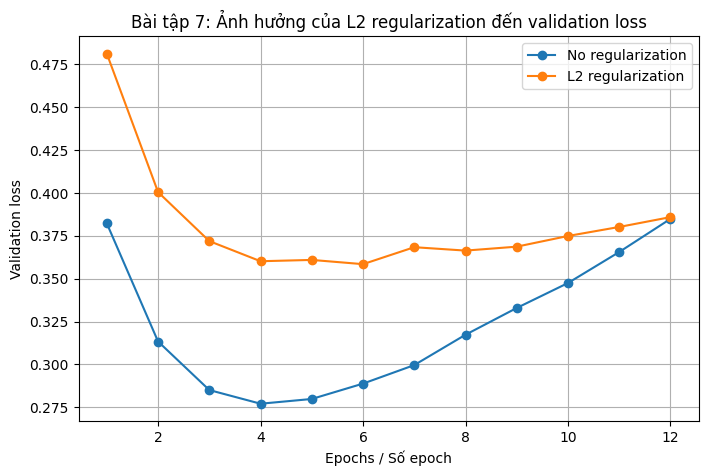

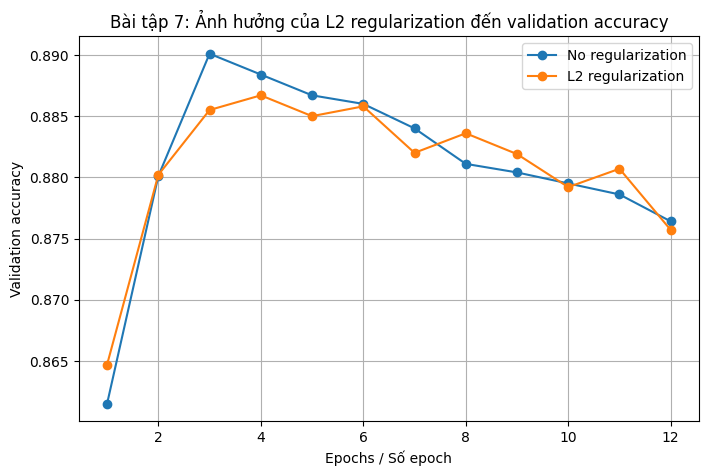

In [15]:
# Model không dùng regularization.
model_no_reg = build_imdb_model(units=16)
history_no_reg = model_no_reg.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# TODO 7.1: Thêm L2 regularization.
# Có thể thử các giá trị: 0.001, 0.002, 0.01
model_l2 = build_imdb_model(
    units=16,
    regularizer=regularizers.l2(0.002)
)
history_l2 = model_l2.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

plot_compare_histories(
    {
        "No regularization": history_no_reg,
        "L2 regularization": history_l2
    },
    metric="val_loss",
    title="Bài tập 7: Ảnh hưởng của L2 regularization đến validation loss",
    ylabel="Validation loss"
)

plot_compare_histories(
    {
        "No regularization": history_no_reg,
        "L2 regularization": history_l2
    },
    metric="val_accuracy",
    title="Bài tập 7: Ảnh hưởng của L2 regularization đến validation accuracy",
    ylabel="Validation accuracy"
)

### Câu hỏi phân tích bài 7

1. Model có L2 có overfit chậm hơn không?

    Có, model có L2 overfit chậm hơn vì sau epoch 4, đường validation loss của nó tăng lên rất chậm và thoải so với độ dốc lớn của model không sử dụng regularization.

2. Validation loss của model L2 có ổn định hơn không?

    Có, giá trị validation loss của model L2 duy trì trong khoảng hẹp (từ 0.36 đến 0.38) từ epoch 4 đến 12, không bị tăng vọt nhanh chóng như model "No regularization".

3. Vì sao L2 phạt weights lớn có thể giúp model generalize tốt hơn?

    Việc phạt các trọng số lớn ép model phải học những đặc trưng tổng quát và đơn giản hơn, tránh việc quá phụ thuộc vào các nhiễu (noise) trong dữ liệu train, từ đó giúp duy trì độ chính xác ổn định trên dữ liệu validation.

4. Nếu hệ số L2 quá lớn, chuyện gì có thể xảy ra?

    Nếu hệ số L2 quá lớn, các trọng số sẽ bị ép về gần bằng 0, khiến model trở nên quá đơn giản (underfit) và không đủ khả năng học các pattern quan trọng, dẫn đến cả training loss và validation loss đều cao.

# Bài tập 8 – Dropout

## Mục tiêu

Hiểu Dropout là kỹ thuật regularization bằng cách tắt ngẫu nhiên một phần activation trong training.

Nhiệm vụ:

- Train model gốc.
- Train model có Dropout.
- So sánh validation loss.

Gợi ý:

- Thử `dropout_rate=0.5`.
- Có thể thử thêm `0.2` hoặc `0.3` nếu còn thời gian.

Epoch 1/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.7648 - loss: 0.5603 - val_accuracy: 0.8546 - val_loss: 0.4267
Epoch 2/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8908 - loss: 0.3477 - val_accuracy: 0.8816 - val_loss: 0.3265
Epoch 3/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9159 - loss: 0.2565 - val_accuracy: 0.8821 - val_loss: 0.3009
Epoch 4/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9327 - loss: 0.2082 - val_accuracy: 0.8867 - val_loss: 0.2806
Epoch 5/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9414 - loss: 0.1764 - val_accuracy: 0.8867 - val_loss: 0.2785
Epoch 6/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9535 - loss: 0.1487 - val_accuracy: 0.8849 - val_loss: 0.2835
Epoch 7/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9611 - loss: 0.1268 - val_accuracy: 0.8847 - val_loss: 0.2926
Epoch 8/12
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9691 - loss: 0.1090 - val_accuracy: 0.8823 - v

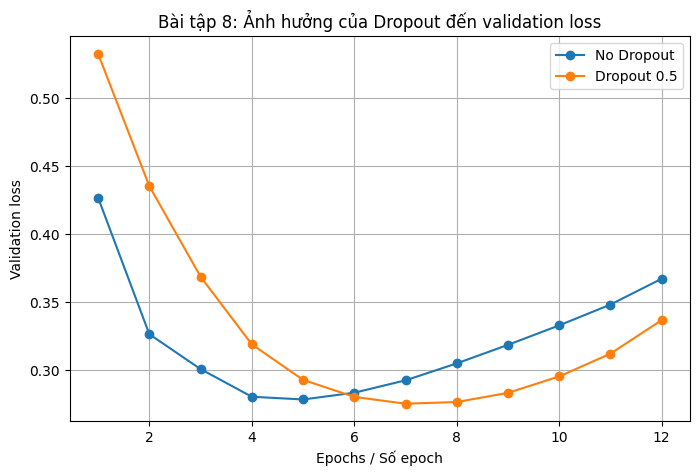

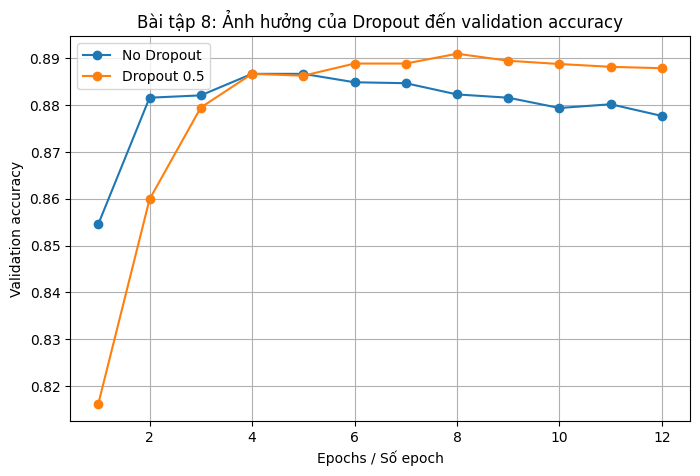

In [16]:
# Model gốc.
model_no_dropout = build_imdb_model(units=16)
history_no_dropout = model_no_dropout.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

# TODO 8.1: Tạo model có Dropout.
model_dropout = build_imdb_model(units=16, dropout_rate=0.5)
history_dropout = model_dropout.fit(
    x_train,
    y_train,
    epochs=IMDB_EPOCHS,
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

plot_compare_histories(
    {
        "No Dropout": history_no_dropout,
        "Dropout 0.5": history_dropout
    },
    metric="val_loss",
    title="Bài tập 8: Ảnh hưởng của Dropout đến validation loss",
    ylabel="Validation loss"
)

plot_compare_histories(
    {
        "No Dropout": history_no_dropout,
        "Dropout 0.5": history_dropout
    },
    metric="val_accuracy",
    title="Bài tập 8: Ảnh hưởng của Dropout đến validation accuracy",
    ylabel="Validation accuracy"
)

### Câu hỏi phân tích bài 8

1. Dropout có làm validation loss tăng chậm hơn không?

    Có, biểu đồ hình 2 cho thấy sau epoch 7, đường "Dropout 0.5" có độ dốc tăng lên thoải hơn nhiều so với đường "No Dropout", giúp trì hoãn hiện tượng quá khớp (overfitting).

2. Vì sao Dropout giúp model không phụ thuộc quá nhiều vào một vài neuron?

    Bằng cách ngẫu nhiên loại bỏ các kết nối trong quá trình huấn luyện, Dropout buộc model phải phân phối việc học đều trên tất cả các neuron thay vì dựa dẫm vào một nhóm nhỏ các trọng số lớn.

3. Dropout có được áp dụng ở test/inference time không?

    Không, Dropout chỉ được sử dụng trong quá trình huấn luyện để tạo tính tổng quát; khi dự báo (inference), tất cả các neuron đều hoạt động để đảm bảo tính ổn định và độ chính xác tối đa.

4. Nếu dropout rate quá cao, model có thể gặp vấn đề gì?

    Nếu tỉ lệ Dropout quá cao (ví dụ > 0.8), model sẽ bị mất quá nhiều thông tin trong mỗi bước học, dẫn đến việc không thể hội tụ (underfitting) và làm giảm đáng kể độ chính xác như đã thấy ở các epoch đầu

# Bài tập 9 – Early stopping

## Mục tiêu

Hiểu early stopping là kỹ thuật dừng training khi validation performance không còn cải thiện.

Trong thực tế, ta thường không muốn train đến epoch cuối nếu validation loss đã bắt đầu tăng.

Nhiệm vụ:

- Train model với số epoch lớn.
- Dùng `EarlyStopping` để tự động dừng sớm.
- So sánh số epoch thực tế đã train với số epoch tối đa.

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.7888 - loss: 0.5482 - val_accuracy: 0.8564 - val_loss: 0.4264
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.8888 - loss: 0.3515 - val_accuracy: 0.8784 - val_loss: 0.3285
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.9127 - loss: 0.2615 - val_accuracy: 0.8861 - val_loss: 0.2910
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9269 - loss: 0.2115 - val_accuracy: 0.8892 - val_loss: 0.2775
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9389 - loss: 0.1787 - val_accuracy: 0.8886 - val_loss: 0.2770
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9487 - loss: 0.1538 - val_accuracy: 0.8862 - val_loss: 0.2819
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9592 - loss: 0.1293 - val_accuracy: 0.8841 - val_loss: 0.2917
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9637 - loss: 0.1161 - val_accuracy: 0.8833 - v

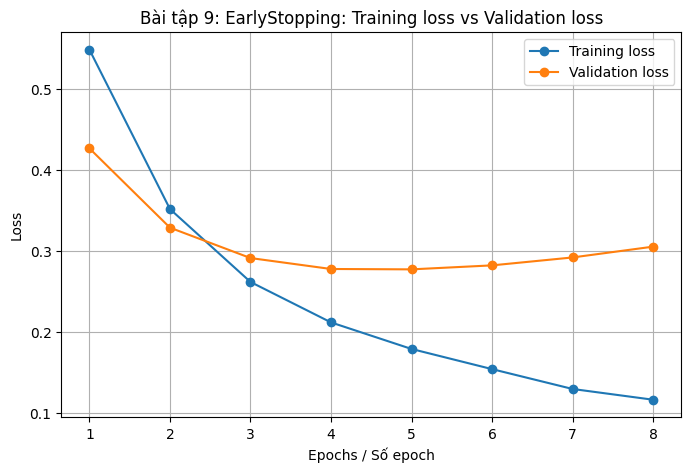

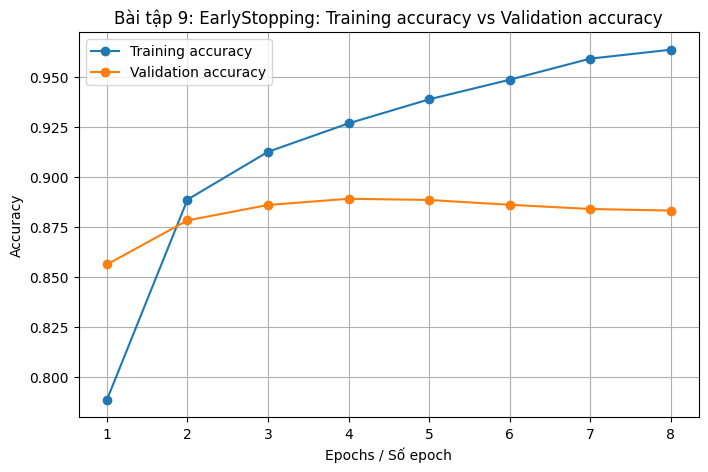

Số epoch thực tế đã train: 8
Metric: val_loss
Epoch tốt nhất: 5
Giá trị tốt nhất: 0.2770
Test loss với EarlyStopping: 0.2910
Test accuracy với EarlyStopping: 0.8831


In [17]:
# TODO 9.1: Tạo callback EarlyStopping.
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",          # Theo dõi validation loss
    patience=3,                  # Chờ 3 epoch không cải thiện rồi dừng
    restore_best_weights=True    # Khôi phục weights tốt nhất
)

model_early = build_imdb_model(units=16)
history_early = model_early.fit(
    x_train,
    y_train,
    epochs=50,                   # Đặt lớn để callback có cơ hội dừng sớm
    batch_size=IMDB_BATCH_SIZE,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

plot_train_val(history_early, title_prefix="Bài tập 9: EarlyStopping")
print("Số epoch thực tế đã train:", len(history_early.history["loss"]))
print_best_validation_result(history_early, metric="val_loss", mode="min")

# Đánh giá model early stopping trên test set.
test_loss_early, test_acc_early = model_early.evaluate(x_test, y_test, verbose=0)
print(f"Test loss với EarlyStopping: {test_loss_early:.4f}")
print(f"Test accuracy với EarlyStopping: {test_acc_early:.4f}")

### Câu hỏi phân tích bài 9

1. Model dừng ở epoch bao nhiêu?
    
    Model dừng lại ở epoch 8, vì đây là số epoch thực tế đã thực hiện trước khi Early Stopping kích hoạt.

2. Epoch có validation loss tốt nhất là epoch nào?

    Epoch có validation loss tốt nhất là epoch 5 với giá trị thấp nhất đạt được là 0.2770.

3. Vì sao `restore_best_weights=True` hữu ích?

    Tham số này cực kỳ quan trọng vì nó giúp model tự động quay lại và sử dụng các trọng số tại epoch có kết quả tốt nhất (epoch 5), thay vì giữ lại trọng số tại epoch cuối cùng khi đã bắt đầu bị overfit (epoch 8).

4. Early stopping khác gì với việc train cố định 20 epoch?

    Khác với việc train cố định dễ dẫn đến lãng phí tài nguyên và gây overfit nặng, Early Stopping giúp tối ưu thời gian huấn luyện và dừng đúng lúc khi model không còn cải thiện trên tập validation, giúp bảo đảm khả năng generalization tốt hơn.


# Bài tập 10 – Tổng hợp: chọn model tốt nhất

## Mục tiêu

Sinh viên tổng hợp kết quả từ các bài trước để chọn model phù hợp nhất.

Hãy so sánh các model IMDB đã train:

- Basic model
- Small model
- Large model
- L2 model
- Dropout model
- EarlyStopping model

Tiêu chí so sánh:

- Validation loss thấp nhất.
- Validation accuracy cao nhất.
- Khoảng cách giữa training và validation có quá lớn không.
- Model có overfit nhanh không.
- Model có quá phức tạp không.

In [18]:
# TODO 10.1: Tạo bảng tổng hợp kết quả các model.
# Lưu ý: một số history có thể chưa tồn tại nếu bạn chưa chạy các bài trước.

model_histories = {
    "Basic": history_basic,
    "Small": history_small,
    "Original": history_original,
    "Large": history_large,
    "L2": history_l2,
    "Dropout": history_dropout,
    "EarlyStopping": history_early
}

summary_rows = []
for name, hist in model_histories.items():
    best_val_loss = float(np.min(hist.history["val_loss"]))
    best_val_acc = float(np.max(hist.history["val_accuracy"]))
    best_epoch_loss = int(np.argmin(hist.history["val_loss"])) + 1
    best_epoch_acc = int(np.argmax(hist.history["val_accuracy"])) + 1
    total_epochs = len(hist.history["loss"])

    summary_rows.append([
        name,
        best_val_loss,
        best_epoch_loss,
        best_val_acc,
        best_epoch_acc,
        total_epochs
    ])

# In bảng bằng format đơn giản, không cần pandas.
print("Model | Best val_loss | Epoch loss tốt nhất | Best val_acc | Epoch acc tốt nhất | Tổng epochs")
print("-" * 95)
for row in summary_rows:
    print(f"{row[0]:15s} | {row[1]:.4f} | {row[2]:17d} | {row[3]:.4f} | {row[4]:16d} | {row[5]:11d}")

Model | Best val_loss | Epoch loss tốt nhất | Best val_acc | Epoch acc tốt nhất | Tổng epochs
-----------------------------------------------------------------------------------------------
Basic           | 0.2770 |                 4 | 0.8896 |                4 |          12
Small           | 0.2780 |                11 | 0.8897 |                8 |          12
Original        | 0.2761 |                 5 | 0.8898 |                4 |          12
Large           | 0.2667 |                 3 | 0.8874 |                5 |          12
L2              | 0.3584 |                 6 | 0.8867 |                4 |          12
Dropout         | 0.2754 |                 7 | 0.8910 |                8 |          12
EarlyStopping   | 0.2770 |                 5 | 0.8892 |                4 |           8


### Câu hỏi tổng hợp cuối bài

Trả lời ngắn gọn các câu hỏi sau:

1. Model nào có validation loss thấp nhất? [Large - 0.2667]

2. Model nào có validation accuracy cao nhất? [DropOut - 0.8892]
3. Model nào overfit nhanh nhất? Dựa vào biểu đồ nào? [Large - Epoch loss 3]
4. L2 regularization có cải thiện generalization không?

    Có, L2 giúp ổn định validation loss và giảm tốc độ overfit dù giá trị loss có thể cao hơn.

5. Dropout có cải thiện generalization không?

    Có, Dropout giúp đạt accuracy cao nhất và làm validation loss tăng chậm hơn ở các epoch cuối.

6. Early stopping giúp tránh overfitting như thế nào?

    Dừng huấn luyện ngay khi validation loss ngừng cải thiện, ngăn model học nhiễu ở các epoch sau.

7. Vì sao không nên chọn model chỉ dựa trên training accuracy?

    Training accuracy cao có thể là dấu hiệu của việc model đang "học thuộc lòng" dữ liệu thay vì học các quy luật tổng quát.

8. Theo em, quy trình chọn model hợp lý nên gồm các bước nào?

    Bắt đầu với model đơn giản, tăng capacity dần, sau đó áp dụng Regularization (L2, Dropout) và Early Stopping.

9. Cách chọn được model với capacity vừa đủ?

    Model có validation loss thấp và ổn định nhất, đồng thời khoảng cách giữa training và validation loss là nhỏ nhất.

## Kết luận

Một model tốt không phải là model có training accuracy cao nhất, mà là model có khả năng **generalization / tổng quát hóa** tốt nhất trên dữ liệu chưa từng thấy.